# Sanity check for making sure our beds match the conditioning data
Mickey MacKie
4/15/26

We have been encountering some head-scratching issues related to bed results not matching the conditioning data and we don't quite know why! Please use this script to check your beds and help us diagnose what's going on.

Make sure to use the conditioning data from here: https://www.dropbox.com/scl/fi/uy5o63indt5rgdplumkhx/bedmap3_raw_thick_compilation.npy?rlkey=9lx25knk431g1udy6cty6syau&st=sh1jowzb&dl=0 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import cmocean

In [2]:
# load compiled bed elevation measurements
df = pd.read_csv('RutfordDataGridded.csv')

# # load an example SGS realization
# #sgs = pd.read_csv('Cook/Cook_sgs_bed_0.txt')
# sgs = np.loadtxt('Cook/sgs_bed_cook.txt')

# # load an example large-scale chain output
# lsc = np.loadtxt('Cook/Cook_beds_800000.txt') # your file will probably have a different naming. Might need to use np.load instead

# load the most up to date conditioning data
radar_thickness = np.load('../../DEMOGORGN data/bedmap3_raw_thick_compilation.npy')

In [3]:
# create a grid of x and y coordinates (use your coordinates from T1)
xmin = -1425250
xmax = -1225250
ymin = 80250
ymax = 197250

resolution = 500

xx, yy = np.meshgrid(np.arange(xmin, xmax, resolution), 
                     np.arange(ymin, ymax, resolution))

In [4]:
xmin_ant = -3333250
xmax_ant = 3333250
ymin_ant = -3333250
ymax_ant = 3333250

xx_ant, yy_ant = np.meshgrid(np.arange(xmin_ant, xmax_ant + resolution, resolution), 
                     np.arange(ymin_ant, ymax_ant + resolution, resolution))

In [5]:
xmin_ind = np.where(xx_ant == xmin)[1][0]
xmax_ind = np.where(xx_ant == xmax)[1][0]
ymin_ind = np.where(yy_ant == ymin)[0][0]
ymax_ind = np.where(yy_ant == ymax)[0][0]

In [6]:
radar_thickness = np.load('../../DEMOGORGN data/bedmap3_raw_thick_compilation.npy')
radar_thickness = np.flip(radar_thickness,axis=0)
radar_thickness = radar_thickness[ymin_ind:ymax_ind,xmin_ind:xmax_ind]

(-1425500.0, -1225500.0, 80000.0, 197000.0)

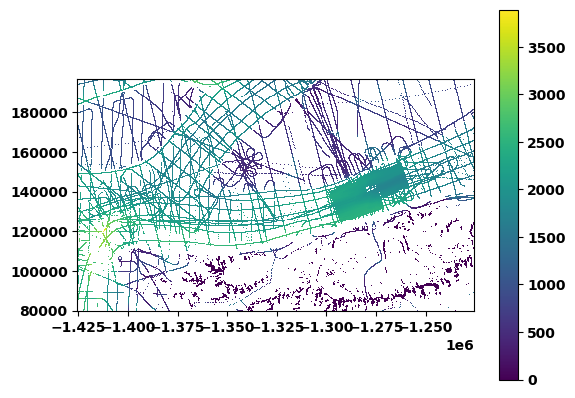

In [7]:
plt.pcolormesh(xx,yy,radar_thickness)
plt.colorbar()
plt.axis('scaled')

In [8]:
# unpack dataframe
dhdt = df['dhdt'].values.reshape(xx.shape)
smb = df['smb'].values.reshape(xx.shape)
velx = df['velx'].values.reshape(xx.shape)
vely = df['vely'].values.reshape(xx.shape)
bedmap_mask = df['bedmap_mask'].values.reshape(xx.shape)
bedmachine_thickness = df['bedmachine_thickness'].values.reshape(xx.shape)
bedmap_surf = df['bedmap_surf'].values.reshape(xx.shape)
highvel_mask = df['highvel_mask'].values.reshape(xx.shape)
bedmap_bed = df['bedmap_bed'].values.reshape(xx.shape)

bedmachine_bed = bedmap_surf - bedmachine_thickness

In [9]:
# # pull out conditioning data
# cond_bed = bedmap_surf - radar_thickness

In [10]:
# create conditioning data
# bed elevation measurement in grounded ice region, and bedmap topography elsewhere
cond_bed = np.where(bedmap_mask == 1, df['bed'].values.reshape(xx.shape), bedmap_bed)
df['cond_bed'] = cond_bed.flatten()

In [11]:
#load sgs realizations
n = 10
sgs_beds=[]
for i in range(n):
    file_name='Rutford_sgs_bed_'+str(i)+'.txt'
    sgs_bed = np.loadtxt(file_name)
    thickness = bedmap_surf - sgs_bed
    sgs_bed = np.where((thickness<=0)&(bedmap_mask==1), bedmap_surf-1, sgs_bed)
    sgs_beds.append(sgs_bed)
    
sgs_beds = np.stack(sgs_beds)

In [12]:
#load LSC output
from pathlib import Path
seed_file_path = '../../DEMOGORGN data/200_seeds.txt'

with open(Path(seed_file_path), 'r') as f:
    lines = f.readlines()

rng_seeds = []
for line in lines:
    rng_seeds.append(int(line.strip()))

losses=[]
final_beds=[]
folders=[157654,654803,125068,821861,315470,209073,973960,842002,165589,271381] 
#folders are in order they appear in 200_seeds_txt so indecies match between SGS and LSC beds
final_beds=[]
for folder in folders:
    bed=np.load(f'LargeScaleChain/{folder}/bed_9000k.npy')
    final_beds.append(bed)

Plot data and differences. Make sure to change your glacier name!

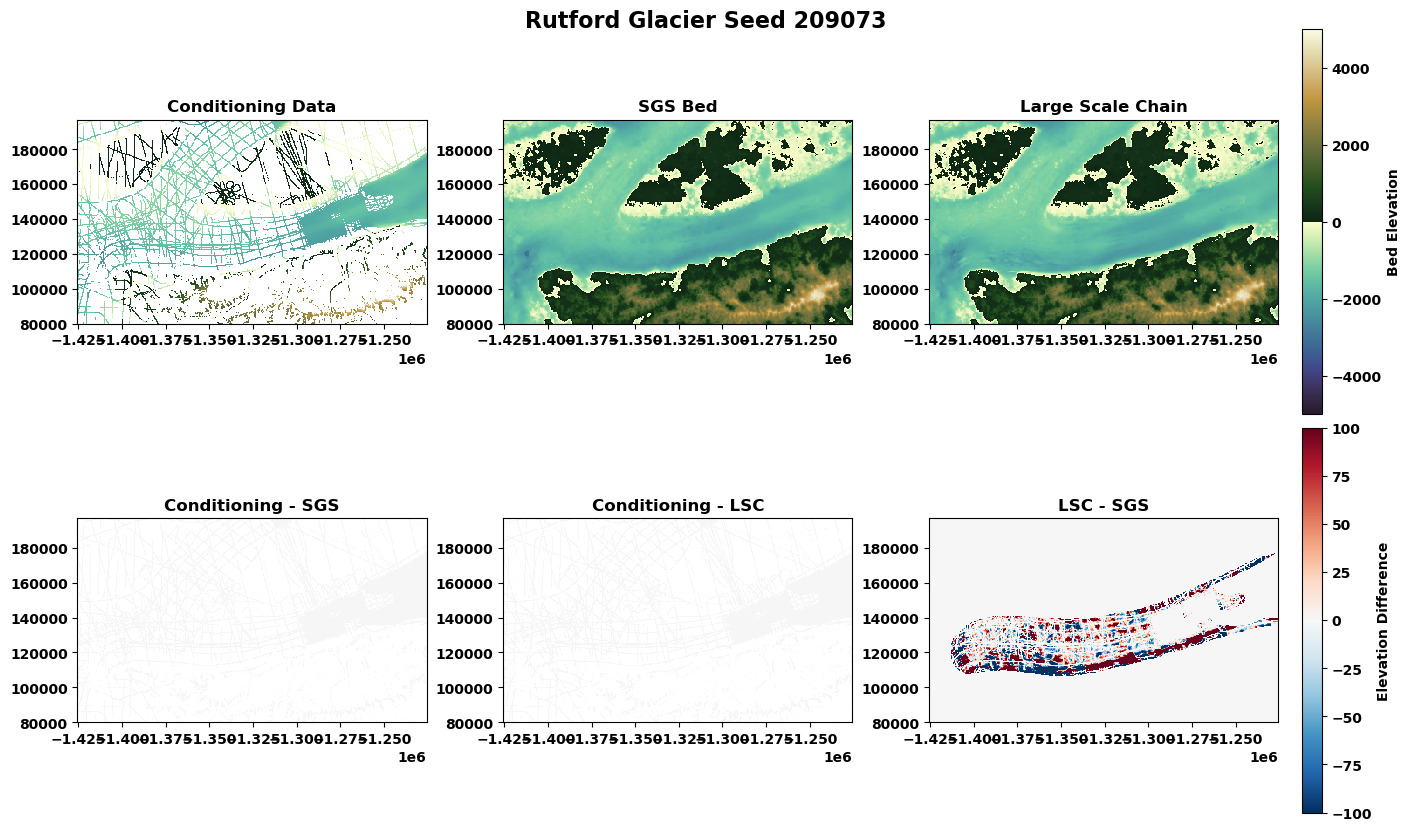

In [16]:
i=5
# --- Consistent color limits for main fields ---
vmin = -5000
vmax = 5000

# --- Differences ---
diff_sgs = cond_bed - sgs_beds[i]
diff_lsc = cond_bed - final_beds[i]
diff_lsc_sgs = final_beds[i] - sgs_beds[i]

# symmetric limits for differences (use ALL diffs)
diff_max = np.nanmax(np.abs([diff_sgs, diff_lsc, diff_lsc_sgs]))
dmin, dmax = -100, 100

# --- Figure ---
fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

# --- Overall title ---
fig.suptitle(f'Rutford Glacier Seed {folders[i]}', fontsize=16, y=1.02)

# =========================
# Top row: original fields
# =========================
im0 = axs[0, 0].pcolormesh(xx, yy, cond_bed, vmin=vmin, vmax=vmax, cmap='cmo.topo')
axs[0, 0].set_title("Conditioning Data")
axs[0, 0].set_aspect('equal')

im1 = axs[0, 1].pcolormesh(xx, yy, sgs_beds[i], vmin=vmin, vmax=vmax, cmap='cmo.topo')
axs[0, 1].set_title("SGS Bed")
axs[0, 1].set_aspect('equal')

im2 = axs[0, 2].pcolormesh(xx, yy, final_beds[i], vmin=vmin, vmax=vmax, cmap='cmo.topo')
axs[0, 2].set_title("Large Scale Chain")
axs[0, 2].set_aspect('equal')

# shared colorbar (top row)
cbar1 = fig.colorbar(im2, ax=axs[0, :], fraction=0.025, pad=0.02)
cbar1.set_label("Bed Elevation")

# =========================
# Bottom row: differences
# =========================
im3 = axs[1, 0].pcolormesh(xx, yy, diff_sgs, vmin=dmin, vmax=dmax, cmap='RdBu_r')
axs[1, 0].set_title("Conditioning - SGS")
axs[1, 0].set_aspect('equal')

im4 = axs[1, 1].pcolormesh(xx, yy, diff_lsc, vmin=dmin, vmax=dmax, cmap='RdBu_r')
axs[1, 1].set_title("Conditioning - LSC")
axs[1, 1].set_aspect('equal')

im5 = axs[1, 2].pcolormesh(xx, yy, diff_lsc_sgs, vmin=dmin, vmax=dmax, cmap='RdBu_r')
axs[1, 2].set_title("LSC - SGS")
axs[1, 2].set_aspect('equal')

# shared colorbar (bottom row)
cbar2 = fig.colorbar(im5, ax=axs[1, :], fraction=0.025, pad=0.02)
cbar2.set_label("Elevation Difference")

plt.show()